# Analyze

## Import Packages

In [1]:
import os
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

## Prepare

In [3]:
STORAGE_DIR = "../input"

In [4]:
OUTPUT_DIR = "../output"

In [8]:
DOC_DIR = "../docu"

In [10]:
FILE_DIR = os.path.join(OUTPUT_DIR, "final_merge_df.csv")

In [12]:
final_merge_df = pd.read_csv(os.path.join(FILE_DIR), encoding="utf-8")

## Inspect

### Formatierung der Variable `date` prüfen

In [235]:
final_merge_df.dtypes

Unnamed: 0          int64
id                 object
title              object
preview            object
date               object
zeitschrift        object
analyse_preview    object
analyse_title      object
dtype: object

In [237]:
final_merge_df["date"].count

<bound method Series.count of 0      2026-01-30
1      2026-01-30
2      2026-01-30
3      2026-01-30
4      2026-01-30
          ...    
678    2025-11-30
679    2025-10-30
680    2025-10-30
681    2025-10-14
682    2025-10-14
Name: date, Length: 683, dtype: object>

### Werte der Variablen `analyse_preview` und `analyse_title` prüfen

**analyse_preview**

In [241]:
analyse_preview_df = final_merge_df.groupby("analyse_preview")["id"].count()

In [243]:
analyse_preview_df

analyse_preview
SKEPSIS        2
Skepsis      559
Vertrauen    122
Name: id, dtype: int64

<Axes: xlabel='analyse_preview'>

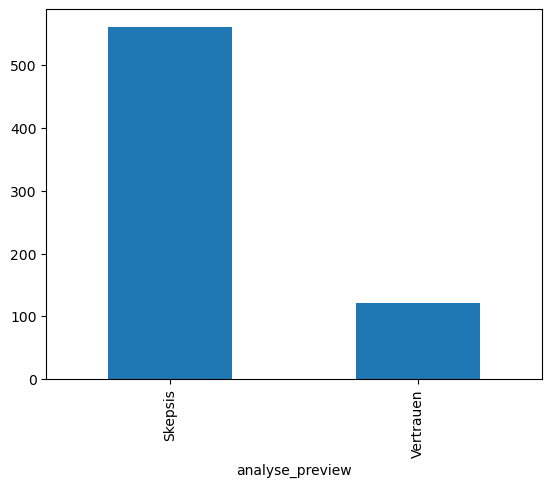

In [74]:
analyse_preview_df.plot.bar()

**analyse_title**

In [24]:
analyse_title_df = final_merge_df.groupby("analyse_title")["id"].count()

In [26]:
analyse_title_df

analyse_title
Skepsis      575
Vertrauen    108
Name: id, dtype: int64

<Axes: xlabel='analyse_title'>

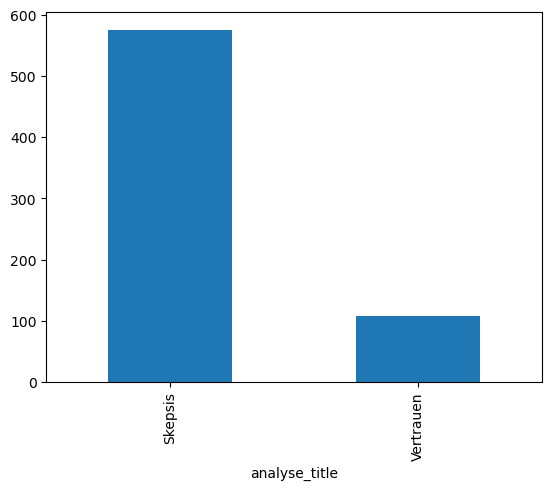

In [81]:
analyse_title_df.plot.bar()

## Transform

### `date`zu datetime umwandeln

In [14]:
final_merge_df["date"] = pd.to_datetime(final_merge_df["date"], dayfirst=True, format="mixed")

### Werte in `analyse_preview` und `analyse_title` vereinheitlichen

In [17]:
final_merge_df["analyse_preview"] = final_merge_df["analyse_preview"].str.replace("SKEPSIS","Skepsis")

In [19]:
final_merge_df["analyse_title"] = final_merge_df["analyse_title"].str.replace("SKEPSIS","Skepsis")

### Datetime to Calenderweek

In [172]:
d_developement = final_merge_df.groupby(['date', 'analyse_preview']).size().unstack(fill_value=0)

In [174]:
d_developement = d_developement.reindex(pd.to_datetime(datum), fill_value=0)

In [176]:
d_developement = d_developement.reset_index().rename(columns={"index":"date"})	

In [178]:
d_developement["calenderweek"] = d_developement["date"].dt.isocalendar().week
d_developement.head(3)

analyse_preview,date,Skepsis,Vertrauen,calenderweek
0,2025-10-14,6,1,42
1,2025-10-15,2,0,42
2,2025-10-16,3,0,42


In [292]:
d_developement.head()

analyse_preview,date,Skepsis,Vertrauen,calenderweek,cw_year
0,2025-10-14,6,1,42,42_25
1,2025-10-15,2,0,42,42_25
2,2025-10-16,3,0,42,42_25
3,2025-10-17,4,1,42,42_25
4,2025-10-18,0,0,42,42_25


In [288]:
d_developement = d_developement.drop(["year"], axis=1)

In [265]:
d_developement["year"] = d_developement["date"].dt.year

In [269]:
d_developement["cw_year"] = d_developement['calenderweek'].astype(str).str.cat(d_developement['year'].astype(str).str[-2:], sep='_')

In [290]:
# Nutze das isocalendar-System für Jahr und Woche gemeinsam
iso_data = d_developement["date"].dt.isocalendar()

# Verbinde die ISO-Woche mit dem ISO-Jahr
d_developement["cw_year"] = iso_data.week.astype(str) + "_" + iso_data.year.astype(str).str[-2:]

In [294]:
d_developement = d_developement.sort_values("date", ascending=True)

In [298]:
d_developement

analyse_preview,date,Skepsis,Vertrauen,calenderweek,cw_year
0,2025-10-14,6,1,42,42_25
1,2025-10-15,2,0,42,42_25
2,2025-10-16,3,0,42,42_25
3,2025-10-17,4,1,42,42_25
4,2025-10-18,0,0,42,42_25
...,...,...,...,...,...
103,2026-01-25,1,0,4,4_26
104,2026-01-26,1,1,5,5_26
105,2026-01-27,2,0,5,5_26
106,2026-01-28,5,0,5,5_26


## Final Visualisation

In [253]:
final_merge_df.head()

,Unnamed: 0,id,title,preview,date,zeitschrift,analyse_preview,analyse_title
0,0,teaser-httpswwwsueddeutschedepolitiksyrien-kur...,Einigung zwischen Kurden und Regierung,Die SDF einigen sich mit der syrischen Regieru...,2026-01-30,sz,Vertrauen,Vertrauen
1,1,teaser-httpswwwsueddeutschedepolitiksyrien-dam...,Damaskus und Kurden beschließen Waffenstillstand,Die kurdisch angeführten Syrischen Demokratisc...,2026-01-30,sz,Vertrauen,Vertrauen
2,2,teaser-httpswwwsueddeutschedemeinungiran-prote...,So verraten die Exil-Iraner ihr eigenes Volk,"Sie sind zerstritten, ja verfeindet. Dabei bra...",2026-01-30,sz,Skepsis,Skepsis
3,3,teaser-httpswwwsueddeutschedepolitikisrael-auc...,Auch die Armee geht von 70 000 Toten in Gaza aus,Israels Militär geht israelischen Medienberich...,2026-01-30,sz,Skepsis,Skepsis
4,4,teaser-httpswwwsueddeutschedepolitiknahost-isr...,Israel will Gaza-Grenze nach Ägypten öffnen,Israel will im Gazastreifen den nach Ägypten f...,2026-01-30,sz,Vertrauen,Skepsis


### Anzahl an Artikel pro Zeitschrift

In [99]:
anzahl_artikel = final_merge_df.groupby("zeitschrift")["id"].count()

<Axes: ylabel='zeitschrift'>

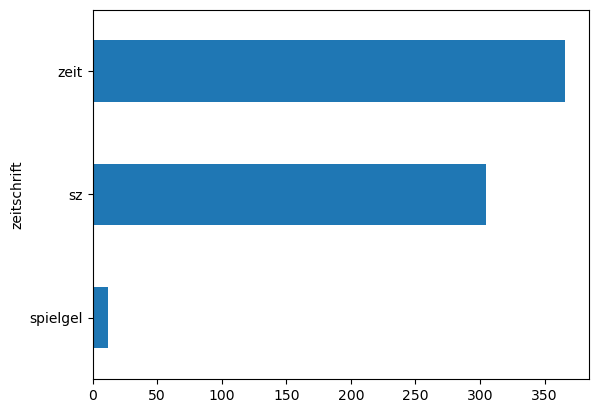

In [116]:
#fig, ax = plt.subplot()

#bahr(anzahl_artikel)

#plt.show()

anzahl_artikel.plot.barh()

### Rel.Häufigkeit: Skepsis vs Vertrauen nach Zeitschrift

### Im Titel

In [21]:
###Skepsis
anzahl_skepsis_title = final_merge_df.loc[final_merge_df["analyse_title"] == "Skepsis"]
groupby_skepsis_title = anzahl_skepsis_title.groupby("zeitschrift")["id"].count()

### Vertrauen
anzahl_vertrauen_title = final_merge_df.loc[final_merge_df["analyse_title"] == "Vertrauen"]
groupby_vertrauen_title = anzahl_vertrauen_title.groupby("zeitschrift")["id"].count()

### In der Vorschau

In [24]:
###Skepsis
anzahl_skepsis_preview = final_merge_df.loc[final_merge_df["analyse_preview"] == "Skepsis"]
skepsis = anzahl_skepsis_preview.groupby("zeitschrift")["id"].count()


### Vertrauen
anzahl_vertrauen_preview = final_merge_df.loc[final_merge_df["analyse_preview"] == "Vertrauen"]
vertrauen = anzahl_vertrauen_preview.groupby("zeitschrift")["id"].count()

In [26]:
len(groupby_vertrauen_title)

3

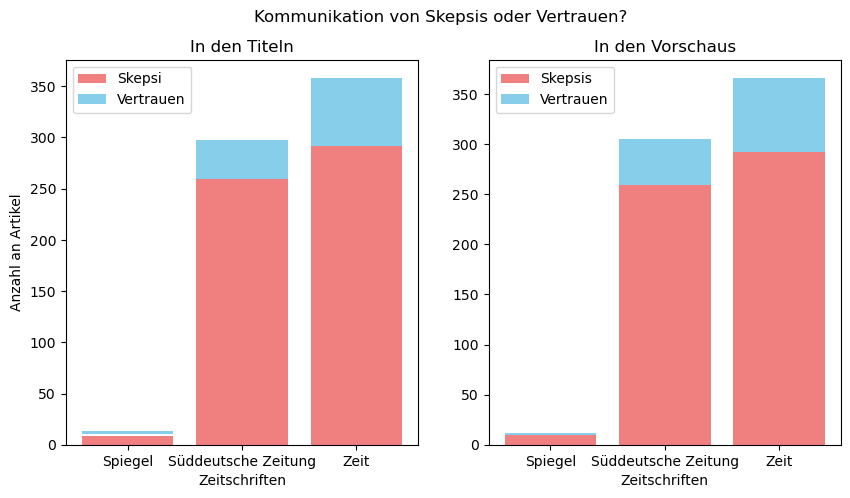

In [28]:
x = ["Spiegel", "Süddeutsche Zeitung", "Zeit"]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))


###1 Axes
ax[0].bar(x, groupby_skepsis_title, label= "Skepsi", color="lightcoral")
ax[0].bar(x, groupby_vertrauen_title, bottom=skepsis, label="Vertrauen", color="skyblue")
ax[0].set_title("In den Titeln")
ax[0].set_xlabel("Zeitschriften")
ax[0].set_ylabel("Anzahl an Artikel")

###2 Axes
ax[1].bar(x, skepsis, label= "Skepsis", color="lightcoral")
ax[1].bar(x, vertrauen, bottom=skepsis, label="Vertrauen", color="skyblue")
ax[1].set_title("In den Vorschaus")
ax[1].set_xlabel("Zeitschriften")


###----Labels
plt.suptitle("Kommunikation von Skepsis oder Vertrauen?")
ax[0].legend()
ax[1].legend()
plt.show()

### Zeitliche Entwicklung: Skepsis vs Vertrauen

ziel-datum (Ereignis): 08.10.2025

Interval im Datensatz:
2026-01-30 - 2025-10-14

In [36]:
datum = np.arange(np.datetime64("2025-10-14"), np.datetime64("2026-01-30"))

In [176]:
skepsis_preview = final_merge_df.loc[final_merge_df["analyse_preview"] == 'Skepsis'].groupby("date")["analyse_preview"].count()

In [180]:
vertrauen_preview = final_merge_df.loc[final_merge_df["analyse_preview"] == 'Vertrauen'].groupby("date")["analyse_preview"].count()

**Note:**

---
Ich muss ein Datum-Array für die X-Achse erstellen

---

In [219]:
d_developement["cw_year"]

0      42_26
1      42_26
2      42_26
3      42_26
4      42_26
       ...  
103     4_26
104     5_26
105     5_26
106     5_26
107     5_26
Name: cw_year, Length: 108, dtype: object

In [164]:
d_developement = final_merge_df.groupby(['date', 'analyse_preview']).size().unstack(fill_value=0)

In [166]:
d_developement = d_developement.reindex(pd.to_datetime(datum), fill_value=0)

In [168]:
d_developement = d_developement.reset_index().rename(columns={"index":"date"})	

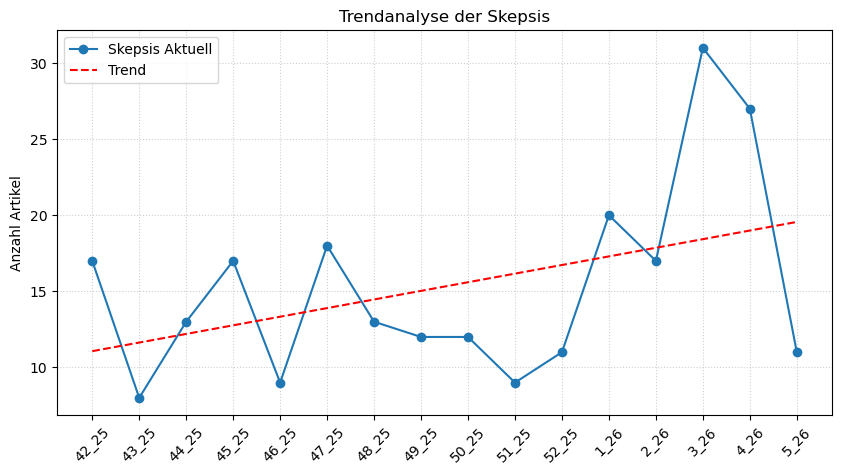

In [300]:
# 1. Daten gruppieren (Wichtig: Wir nutzen d_plot für alles weitere)
d_plot = d_developement.groupby("cw_year", sort=False)[["Skepsis", "Vertrauen"]].sum().reset_index()

# 2. Numerische Vorbereitungen
# Wir nehmen die Werte explizit als Float-Zahlen
y_skepsis = d_plot["Skepsis"].astype(float).values
x_num = np.arange(len(y_skepsis)).astype(float)

# 3. Trendlinie berechnen
# WICHTIG: Hier muss y_skepsis stehen, nicht das alte 'y'
z = np.polyfit(x_num, y_skepsis, 1)
p = np.poly1d(z)

# 4. Plotten
fig, ax = plt.subplots(figsize=(10, 5))

# Originaldaten (Wichtig: x und y müssen die gleiche Länge aus d_plot haben)
ax.plot(d_plot["cw_year"], y_skepsis, label='Skepsis Aktuell', marker='o')

# Trendlinie einbauen
# p(x_num) berechnet die y-Werte der Trendlinie passend zu den x-Labels
ax.plot(d_plot["cw_year"], p(x_num), "r--", label='Trend')

# Formatierung
plt.xticks(rotation=45)
plt.title('Trendanalyse der Skepsis')
plt.ylabel('Anzahl Artikel')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

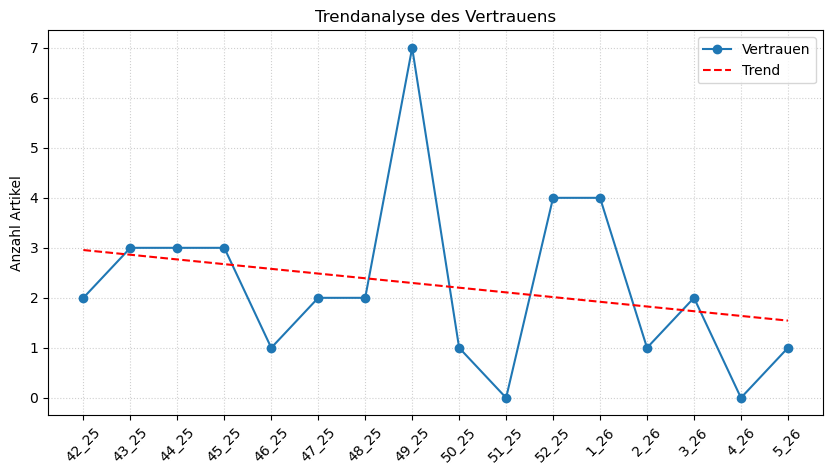

In [302]:
# 1. Daten gruppieren (Wichtig: Wir nutzen d_plot für alles weitere)
d_plot = d_developement.groupby("cw_year", sort=False)[["Skepsis", "Vertrauen"]].sum().reset_index()

# 2. Numerische Vorbereitungen
# Wir nehmen die Werte explizit als Float-Zahlen
y_skepsis = d_plot["Vertrauen"].astype(float).values
x_num = np.arange(len(y_skepsis)).astype(float)

# 3. Trendlinie berechnen
# WICHTIG: Hier muss y_skepsis stehen, nicht das alte 'y'
z = np.polyfit(x_num, y_skepsis, 1)
p = np.poly1d(z)

# 4. Plotten
fig, ax = plt.subplots(figsize=(10, 5))

# Originaldaten (Wichtig: x und y müssen die gleiche Länge aus d_plot haben)
ax.plot(d_plot["cw_year"], y_skepsis, label='Vertrauen', marker='o')

# Trendlinie einbauen
# p(x_num) berechnet die y-Werte der Trendlinie passend zu den x-Labels
ax.plot(d_plot["cw_year"], p(x_num), "r--", label='Trend')

# Formatierung
plt.xticks(rotation=45)
plt.title('Trendanalyse des Vertrauens')
plt.ylabel('Anzahl Artikel')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()